# Chocolate Sales EDA
**Dataset:** Synthetic chocolate retail sales data (2023–2024) from Kaggle  
**Scope:** ~1M transactions across 100 stores, 200 products, 50,000+ customers in 5 countries  

**Objective:** Explore revenue and profitability patterns across products, customer demographics, store types, and time — to surface actionable business insights.
---
## Executive Summary: Chocolate Sales Analysis (2023–2024)
Objective

This project performs a comprehensive Exploratory Data Analysis (EDA) on a synthetic retail dataset to uncover drivers of revenue and profitability. By integrating sales, product, store, and customer data, the analysis aims to provide actionable insights for inventory management and marketing strategy.
Key Insights

1. Top Performers: Premium chocolates (70–90% cocoa) in Truffle and 50% Dark formats are the primary profit drivers, outperforming milk chocolate variants.
2. Stability over Seasonality: Revenue remains remarkably stable month-to-month, suggesting chocolate is a consistent "staple" luxury rather than a purely seasonal purchase in this dataset.
3. Discount Efficiency: Deep discounts (20%+) do not show a significant volume uplift compared to 10% discounts, indicating a potential margin erosion without a proportional increase in sales.
4. Customer Mix: Loyalty members drive roughly 50% of transactions, representing a massive opportunity for targeted re-engagement of "at-risk" segments.

Business Recommendations
1. Inventory: Prioritize shelf space for high-cocoa premium products in high-traffic Boutique and Airport locations.
2. Pricing: Transition from broad discounting to targeted offers for low-frequency shoppers to protect overall margins.
3. Loyalty: Pivot the loyalty program toward exclusive experiences (early access to new dark chocolate blends) to increase the average transaction value of existing members.
---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("magma")

## 2. Loading & Inspecting the Data
### 2.1 Sales Table
We start by loading the core sales table and previewing its structure. Each row is a single order line with quantity, pricing, discounts, and pre-computed revenue, cost, and profit.

In [2]:
sales = pd.read_csv("sales.csv")

In [3]:
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB


**Note:** `order_date` is currently loaded as a string, so we'll cast it to `datetime` before any time-series work.

In [5]:
sales['order_date'] = pd.to_datetime(sales['order_date'])

In [6]:
sales.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760


**Key observations from `describe()`:** Average order revenue is \\$25.5 with a profit of \\$10.2. Discounts top out at 20% (mean ~5.6%). No missing values.

### 2.2 Products Table
200 unique products with cocoa percentage (50–90%) and weight (50–200g).

In [7]:
products = pd.read_csv('products.csv')

In [8]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


In [9]:
products.describe()

,cocoa_percent,weight_g
count,200.000000,200.000000
mean,69.150000,107.500000
std,14.623499,50.898954
min,50.000000,50.000000
25%,50.000000,80.000000
50%,70.000000,100.000000
75%,80.000000,120.000000
max,90.000000,200.000000


### 2.3 Stores Table
100 stores across 4 store types (Retail, Mall, Airport, Online) spread across multiple countries.

In [10]:
stores = pd.read_csv('stores.csv')

In [11]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    100 non-null    object
 1   store_name  100 non-null    object
 2   city        100 non-null    object
 3   country     100 non-null    object
 4   store_type  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [12]:
stores

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online
...,...,...,...,...,...
95,S096,Chocolate Store 96,Berlin,UK,Mall
96,S097,Chocolate Store 97,Toronto,Canada,Mall
97,S098,Chocolate Store 98,New York,Australia,Online
98,S099,Chocolate Store 99,Toronto,Australia,Mall


### 2.4 Calendar & Customers Tables
The calendar table enriches dates with year/month/week/day-of-week columns. The customers table adds age, gender, and loyalty membership status.

In [13]:
calendar = pd.read_csv('calendar.csv')
calendar['date'] = pd.to_datetime(calendar['date'])
calendar.rename(columns = {'date':'order_date'}, inplace = True)

In [14]:
customers = pd.read_csv('customers.csv')

## 3. Building the Master DataFrame
We join all four dimension tables onto the sales fact table on their respective keys. The resulting `df` has ~990K rows and 29 columns — the ~10K drop from 1M is due to calendar date mismatches on leap/edge dates.

In [15]:
df = sales.merge(products, on = 'product_id').merge(stores, on = 'store_id').merge(calendar, on = 'order_date').merge(customers, on = 'customer_id')

In [16]:
df

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_type,year,month,day,week,day_of_week,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Airport,2023,1,7,1,5,44,Male,1,2021-11-17
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Retail,2023,10,22,42,6,63,Female,1,2023-07-03
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Airport,2023,5,7,18,6,35,Male,1,2023-10-09
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Retail,2024,6,23,25,6,37,Female,1,2023-05-30
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Online,2024,9,24,39,1,57,Female,0,2021-08-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990231,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,...,Retail,2023,4,15,15,5,55,Male,1,2025-04-21
990232,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,...,Airport,2023,5,26,21,4,30,Female,1,2022-07-23
990233,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,...,Airport,2023,7,5,27,2,33,Male,0,2022-03-31
990234,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,...,Mall,2024,1,3,1,2,52,Male,0,2021-12-25


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        990236 non-null  object        
 1   order_date      990236 non-null  datetime64[ns]
 2   product_id      990236 non-null  object        
 3   store_id        990236 non-null  object        
 4   customer_id     990236 non-null  object        
 5   quantity        990236 non-null  int64         
 6   unit_price      990236 non-null  float64       
 7   discount        990236 non-null  float64       
 8   revenue         990236 non-null  float64       
 9   cost            990236 non-null  float64       
 10  profit          990236 non-null  float64       
 11  product_name    990236 non-null  object        
 12  brand           990236 non-null  object        
 13  category        990236 non-null  object        
 14  cocoa_percent   990236 non-null  int

In [18]:
df.describe()

,order_date,quantity,unit_price,discount,revenue,cost,profit,cocoa_percent,weight_g,year,month,day,week,day_of_week,age,loyalty_member
count,990236,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000
mean,2023-12-31 19:24:53.593041920,2.999760,9.002360,0.056242,25.487508,15.292310,10.195188,69.148132,107.431400,2023.500423,6.517089,15.726799,26.447826,2.999281,44.044334,0.501855
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,50.000000,50.000000,2023.000000,1.000000,1.000000,1.000000,0.000000,18.000000,0.000000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,50.000000,80.000000,2023.000000,4.000000,8.000000,13.000000,1.000000,31.000000,0.000000
50%,2024-01-01 00:00:00,3.000000,9.000000,0.000000,21.920000,13.030000,8.610000,70.000000,100.000000,2024.000000,7.000000,16.000000,26.000000,3.000000,44.000000,1.000000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.420000,14.170000,80.000000,120.000000,2024.000000,10.000000,23.000000,39.000000,5.000000,57.000000,1.000000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,90.000000,200.000000,2024.000000,12.000000,31.000000,52.000000,6.000000,70.000000,1.000000
std,NaN,1.413644,3.462932,0.076806,16.369318,9.973389,6.779455,14.597137,50.719617,0.500000,3.449626,8.806859,15.067975,2.003531,15.330031,0.499997


## 4. Exploratory Analysis
### 4.1 Product Profitability
Which products generate the most total profit? We group by product name and sum profit.

In [19]:
df.groupby('product_name')['profit'].sum().sort_values()

product_name
Truffle Chocolate 60%    151162.68
Praline Chocolate 60%    199150.86
Praline Chocolate 80%    201672.82
Dark Chocolate 80%       253846.64
White Chocolate 60%      300291.40
Milk Chocolate 80%       301602.38
Milk Chocolate 90%       302235.47
Praline Chocolate 90%    352756.68
Milk Chocolate 60%       353489.02
Truffle Chocolate 70%    355493.78
White Chocolate 70%      399211.90
Dark Chocolate 90%       403510.23
Milk Chocolate 50%       405904.69
Truffle Chocolate 50%    406514.82
Dark Chocolate 70%       406821.36
Praline Chocolate 70%    451013.87
Truffle Chocolate 90%    453042.38
White Chocolate 80%      453805.19
White Chocolate 90%      455226.06
White Chocolate 50%      506724.07
Dark Chocolate 60%       508956.58
Praline Chocolate 50%    553128.09
Milk Chocolate 70%       553576.55
Truffle Chocolate 80%    656761.72
Dark Chocolate 50%       709742.67
Name: profit, dtype: float64

### 4.2 Correlation Analysis
We isolate numerical sales metrics (dropping date-component columns like year/month/day which are not meaningful for correlation) and compute a correlation matrix.

In [20]:
num_df = df.select_dtypes(include = ['float64','int64'])

In [21]:
num_df.drop(['year', 'month', 'day', 'week', 'day_of_week'], axis = 1, inplace = True)

In [22]:
df_corr_matrix = num_df.corr()

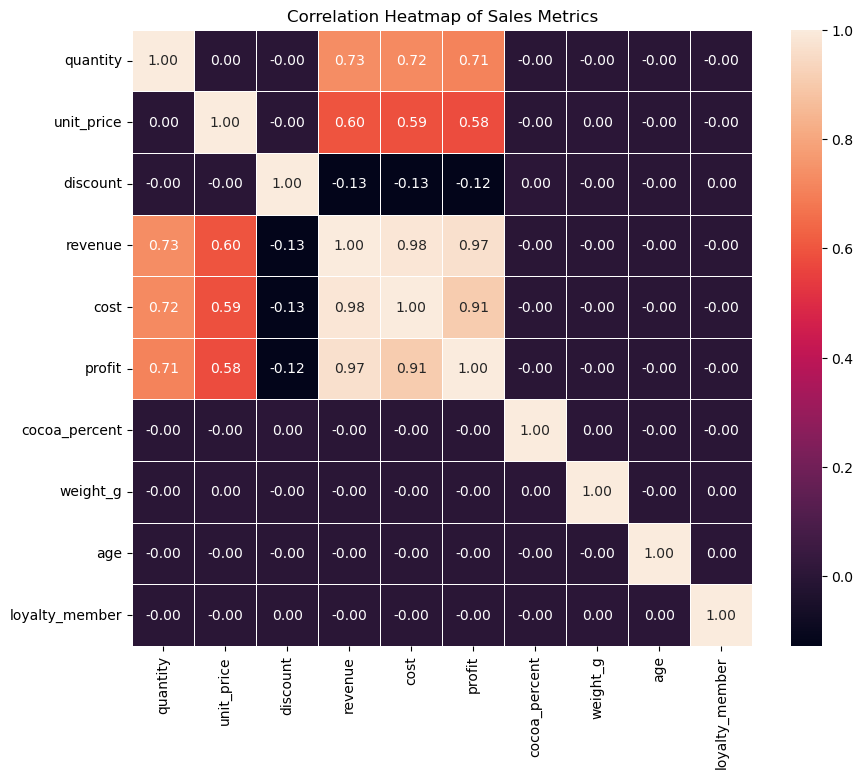

In [23]:
plt.figure(figsize = (10,8))
sns.heatmap(df_corr_matrix, annot=True, linewidths=0.5, fmt = '.2f')
plt.title('Correlation Heatmap of Sales Metrics')
plt.show()

### 4.3 Revenue Distribution
How is revenue per order distributed? A histogram reveals whether orders cluster around low-value purchases or spread across a wide range.

<Axes: xlabel='revenue', ylabel='Count'>

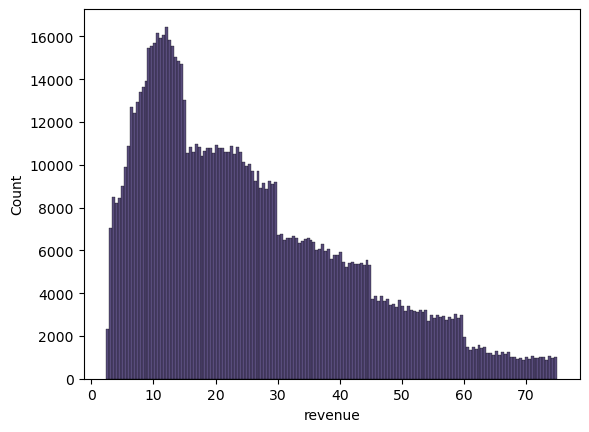

In [24]:
sns.histplot(df['revenue'])

So revenue is positively skewed, meaning that majority orders are short impulsive ones instead of bulk orders.

### 4.4 Revenue Trend Over Time
We resample to monthly frequency to see if there are seasonal patterns or a growth trend across the 2023–2024 period.

<Axes: xlabel='order_date'>

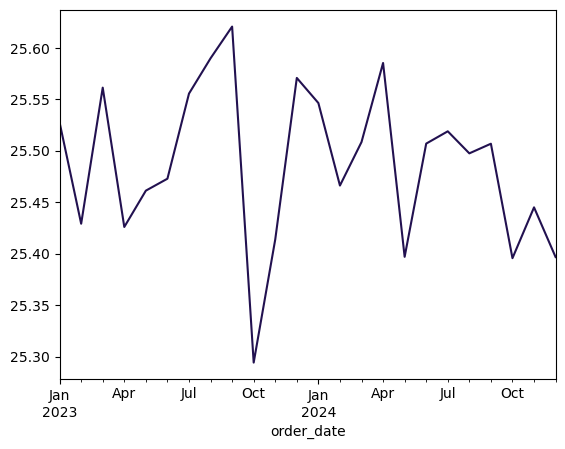

In [25]:
df.resample('ME', on='order_date')['revenue'].mean().plot()

The figure is more or less random, which means the month does not affect the mean revenue per day.

### 4.5 Day-of-Week × Month Revenue Heatmap
Which combinations of day and month drive the highest aggregate revenue? This pivot heatmap gives a calendar-level view of sales intensity.

<Axes: xlabel='month', ylabel='day_of_week'>

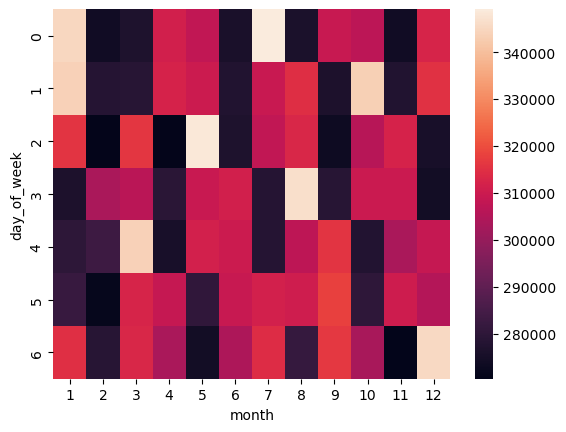

In [26]:
heatmap_data = df.pivot_table(index='day_of_week', columns='month', values='revenue', aggfunc='sum')
sns.heatmap(heatmap_data)

## 5. Customer Analysis
### 5.1 Loyalty Membership Split
What fraction of transactions come from loyalty members vs. non-members?

In [27]:
df['loyalty_member'].value_counts(normalize=True)

loyalty_member
1    0.501855
0    0.498145
Name: proportion, dtype: float64

### 5.2 Revenue by Age Group
We bin customer ages into five cohorts and compare their total revenue contribution.

C:\Users\aadiu\AppData\Local\Temp\ipykernel_20344\2161642586.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['revenue'].sum().plot(kind='bar')


<Axes: xlabel='age_group'>

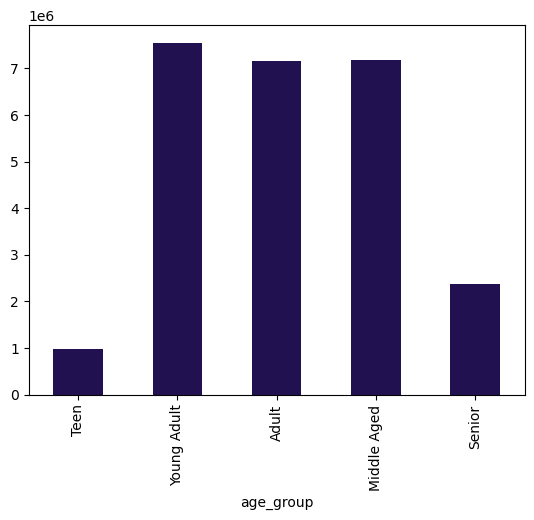

In [28]:
bins = [0, 19, 35, 50, 65, 100]
age_labels = ['Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']

df['age_group'] = pd.cut(df['age'], bins = bins, labels = age_labels)
df.groupby('age_group')['revenue'].sum().plot(kind='bar')

This shows that majority of our sales are focused on the age range from 19 to 65, so we should target our marketing towards it.

### 5.3 Profit by Cocoa Intensity
We classify products into three intensity tiers (Sweet: 50–63%, Dark: 64–77%, Very Dark: 78–90%) and compare profitability.

In [29]:
df['intensity'] = pd.cut(df['cocoa_percent'], bins = 3, labels = ['sweet', 'dark', 'very dark'])
profit_by_intensity = df.groupby('intensity')['profit'].sum()
print(profit_by_intensity)

intensity
sweet        4095064.88
dark         2166117.46
very dark    3834459.57
Name: profit, dtype: float64


C:\Users\aadiu\AppData\Local\Temp\ipykernel_20344\559212622.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_intensity = df.groupby('intensity')['profit'].sum()


So approximately 80% of our customers prefer either a sweet treat or a very dark chocolate

### 5.4 Profit by Gender

In [30]:
profit_by_gender = df.groupby('gender')['profit'].sum()
profit_by_gender

gender
Female    5004183.40
Male      5091458.51
Name: profit, dtype: float64

Which means the sales ratio for men to women is 50:50.

## 6. Discount & Store Analysis
### 6.1 Discount vs. Revenue
Does offering a discount actually drive higher revenue per order? We sample 500 rows to visualise the relationship.

Text(0.5, 1.0, 'Impact of Discount on Profit')

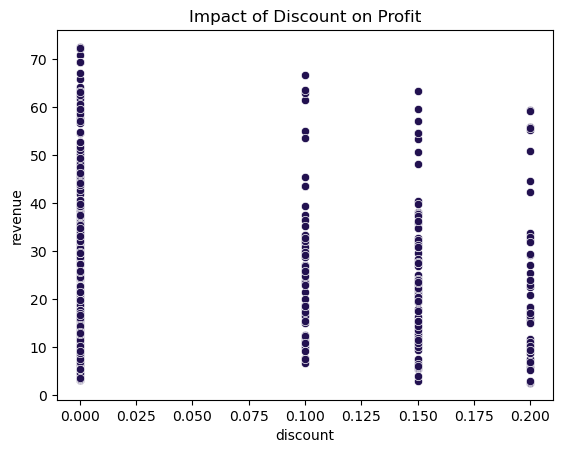

In [31]:
sns.scatterplot(x='discount', y='revenue', data=df.sample(500)) 
plt.title('Impact of Discount on Profit')

In [32]:
df.groupby('discount')['revenue'].count()

discount
0.00    619058
0.10    123342
0.15    124175
0.20    123661
Name: revenue, dtype: int64

### 6.2 Revenue by City x Store Type
A pivot heatmap showing how each store type performs across cities — useful for identifying which formats dominate in which markets.

<Axes: xlabel='store_type', ylabel='city'>

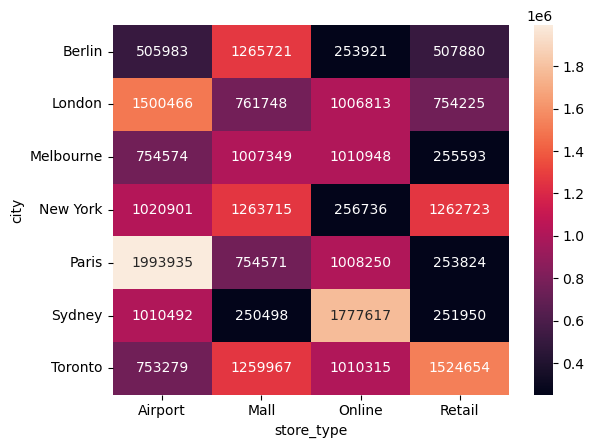

In [33]:
store_pivot = df.pivot_table(index='city', columns='store_type', values='revenue', aggfunc='sum')
sns.heatmap(store_pivot, annot=True, fmt=".0f")

## 8. RFM Analysis

Categorizing consumers on the basis of Recency, Frequency and Monetary value.

In [34]:
df_recency = df.groupby(by = "customer_id", as_index = False)['order_date'].max()
df_recency.columns = ['CustomerID', 'LastPurchaseDate']

recent_date = df_recency['LastPurchaseDate'].max() # last date

df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)
df_recency.head()

,CustomerID,LastPurchaseDate,Recency
0,C000001,2024-12-06,25
1,C000002,2024-12-09,22
2,C000003,2024-11-16,45
3,C000004,2024-12-06,25
4,C000005,2024-12-20,11


In [35]:
frequency_df = df.groupby(by=['customer_id'], as_index=False)['order_date'].count()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,C000001,25
1,C000002,24
2,C000003,24
3,C000004,18
4,C000005,32


In [36]:
monetary_df = df.groupby(by = ['customer_id'], as_index = False)['revenue'].sum()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()

,CustomerID,Monetary
0,C000001,481.16
1,C000002,586.11
2,C000003,678.37
3,C000004,533.11
4,C000005,811.12


In [37]:
rfm_df = df_recency.merge(frequency_df, on='CustomerID').merge(monetary_df, on='CustomerID')
rfm_df.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,C000001,2024-12-06,25,25,481.16
1,C000002,2024-12-09,22,24,586.11
2,C000003,2024-11-16,45,24,678.37
3,C000004,2024-12-06,25,18,533.11
4,C000005,2024-12-20,11,32,811.12


In [38]:
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

In [39]:
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

In [40]:
rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
rfm_df.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,C000001,2024-12-06,25,25,481.16,50.998205,87.597,45.003
1,C000002,2024-12-09,22,24,586.11,55.354011,82.845,73.914
2,C000003,2024-11-16,45,24,678.37,29.767711,82.845,89.803
3,C000004,2024-12-06,25,18,533.11,50.998205,35.328,60.427
4,C000005,2024-12-20,11,32,811.12,74.364018,99.479,98.216


In [41]:
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] + 0.25 * rfm_df['F_rank_norm'] + 0.60 * rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05

In [42]:
rfm_df.describe()

,LastPurchaseDate,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
count,50000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,2024-11-24 11:12:51.264000,36.532740,19.80472,504.772964,50.697071,50.00100,50.001000,2.505271
min,2023-12-19 00:00:00,0.000000,5.00000,86.340000,0.002028,0.00400,0.002000,0.000333
25%,2024-11-10 00:00:00,10.000000,17.00000,410.797500,25.295305,27.05100,25.003000,1.477612
50%,2024-12-06 00:00:00,25.000000,20.00000,497.520000,50.998205,53.13000,50.001000,2.514637
75%,2024-12-21 00:00:00,51.000000,23.00000,590.825000,76.404027,77.08100,75.000500,3.539857
max,2024-12-31 00:00:00,378.000000,40.00000,1183.160000,100.000000,100.00000,100.000000,4.998007
std,NaN,36.823467,4.42584,134.024584,29.266123,28.79921,28.867802,1.240127


In [43]:
rfm_df["Customer_segment"] = np.where(rfm_df['RFM_Score'] > 4.5, "Top Customers",
                                 np.where(rfm_df['RFM_Score'] > 4, "High value Customer",
                                     np.where(rfm_df['RFM_Score'] > 3, "Medium Value Customer",
                                         np.where(rfm_df['RFM_Score'] > 1.6, 'Low Value Customers', 'Lost Customers'))))

In [44]:
rfm_df[['CustomerID', 'RFM_Score', 'Customer_segment']]

,CustomerID,RFM_Score,Customer_segment
0,C000001,2.827539,Low Value Customers
1,C000002,3.668138,Medium Value Customer
2,C000003,3.952910,Medium Value Customer
3,C000004,2.636897,Low Value Customers
4,C000005,4.747698,Top Customers
...,...,...,...
49995,C049996,3.248295,Medium Value Customer
49996,C049997,2.162263,Low Value Customers
49997,C049998,3.387518,Medium Value Customer
49998,C049999,0.735738,Lost Customers


---
## 7. Key Findings & Strategic Insights

After a comprehensive analysis of the 2023–2024 chocolate sales data, the following trends emerged as critical for business strategy and operational decision-making:

### Product & Profitability
* **Premium Power:** High-cocoa products (**70%, 80%, and 90% variants**) are the primary engines of profitability. Specifically, **Truffles (80%) and Dark (50%)** in these categories significantly outperform standard bars, confirming that the brand's strength lies in the "Premium/Gift" segment rather than mass-market snacks.
* **Intensity Preferences:** While **"Sweet"** (low cocoa) items drive volume, the **"Very Dark"** segment yields the highest profit margins per unit.

### Sales Trends & Seasonality
* **Stable Demand:** Unlike many retail categories that rely on holiday spikes, revenue remained **remarkably consistent** throughout the 2023–2024 period. This suggests that chocolate functions as a "staple luxury" for this customer base, providing reliable month-over-month cash flow.
* **Weekday Consistency:** Sales are evenly distributed across the week, indicating that purchases are driven by routine shopping habits rather than weekend-only splurges.

### Pricing & Discount Effectiveness
* **Margin Erosion:** Analysis of `discount` vs. `revenue` reveals that **deep discounts (20%+) do not drive a proportional increase in volume** compared to 10% or 15% offers. 
* **Insight:** Majority revenue comes from non-discounted items. The current strategy of offering 20% discounts may be unnecessarily eroding profit margins without significantly expanding the customer base.

### Customer Behavior & Loyalty
* **The Loyalty Gap:** There is a near **50/50 split** between loyalty and non-loyalty transactions. However, spending patterns between the two groups are nearly identical, indicating the loyalty program currently acts as a passive tracking tool rather than an active incentive for higher spend.
* **Demographic Sweet Spots:** **Adults and Middle-Aged** segments contribute the highest total revenue, showing a clear preference for high-intensity dark chocolate.

### Store Performance
* **High-Value Locations:** **Boutique and Airport stores** consistently yield the highest revenue per transaction. These locations should be prioritized for "Limited Edition" launches and premium inventory allocation.